In [5]:
import os
import shutil
import random
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [6]:
#On utilise le GPU si il est dispnible, sinon le cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Chemin vers les différents répertoires, le dernier permet de créer le répertoire pour stocker les spectrogrammes qui seront générés
INPUT_DIR = "/kaggle/input/ravdess-emotional-speech-audio"
WORK_DIR = "/kaggle/working"
SPEC_DIR = os.path.join(WORK_DIR, "spectrograms")

#on associe grâce a un dictionnaire, les codes du dataset à une émotion (ces données sont données dans la description du dataset)
emotion_labels = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

#le modèle apprend sur 32 images à la fois 
batch_size = 32

In [7]:
print("ÉTAPE 1: VÉRIFICATION DES SPECTROGRAMMES")

#Ici, comme on a fait tourner le programmes plusieurs fois, pour éviter de recréer à chaque fois des nouveaux spectogrammes, on réutilise ceux qui sont présents depuis la première fois qu'on a lancer le propgramme.
#On vérifie si les dossiers comportant les spectrogrammes existent déjà, si oui alors on continue, sinon on les créer

spectrograms_exist = os.path.exists(SPEC_DIR) and \
                     os.path.exists(os.path.join(SPEC_DIR, 'train')) and \
                     os.path.exists(os.path.join(SPEC_DIR, 'val')) and \
                     os.path.exists(os.path.join(SPEC_DIR, 'test'))


if spectrograms_exist:
    print("Spectrogrammes déjà existants, chargement...")
    
else:
    print("Spectrogrammes non trouvés, création en cours...")
    #Cette fonction permet de convertir les audios en spectrogrammes, on limite la durée à 3 secondes pour uniformiser les entrées et éviter les tailles variables, une fréquence d'échantillonage à 22050 Hz    
    def audio_to_spectrogram(filepath, save_path):
        try:
            y, sr = librosa.load(filepath, sr=22050, duration=3.0)
            #Si audio plus court que 3 secondes, on rempli avec des silences
            if len(y) < sr * 3:
                y = np.pad(y, (0, sr * 3 - len(y)), mode='constant')
            #Normalisation du signal audio
            y = y / (np.max(np.abs(y)) + 1e-6)
            #calcul de Mel spectrogram : représentation fréquentielle 
            mel = librosa.feature.melspectrogram(
                y=y, sr=sr, n_mels=128,
                n_fft=2048, hop_length=512
            )
            #Conversion en dB pour rendre les fréquences différentes plus visibles
            mel_db = librosa.power_to_db(mel, ref=np.max)
            #Normalisation entre 0 et 1
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
            #Enregistrement des spectrogrammes en images
            fig = plt.figure(frameon=False)
            fig.set_size_inches(2.24, 2.24)
            ax = plt.Axes(fig, [0., 0., 1., 1.])
            ax.set_axis_off()
            fig.add_axes(ax)
            ax.imshow(mel_db, aspect='auto', cmap='viridis', origin='lower')
            plt.savefig(save_path, dpi=100)
            plt.close(fig)
            
            return True
            
        except Exception as e:
            print(f"Erreur {filepath}: {e}")
            return False
            
    #On récupère tous les fichiers audios 
    audio_files = []
    for root, _, files in os.walk(INPUT_DIR):
        for f in files:
            if f.endswith(".wav"):
                audio_files.append(os.path.join(root, f))
    
    print(f"Nombre de fichiers audio: {len(audio_files)}")
    #On sépare les données en train, validation et test : 70;15;15
    for split in ['train', 'val', 'test']:
        for emotion in emotion_labels.values():
            os.makedirs(os.path.join(SPEC_DIR, split, emotion), exist_ok=True)
    #on associe les fichiers audios aux émotions qu'on a définit dans le dictionnaire juste avant. 
    #Les données (les numéros) sont dans le nom du fichier 
    emotion_files = {emotion: [] for emotion in emotion_labels.values()}
    
    for audio_path in audio_files:
        fn = os.path.basename(audio_path)
        parts = fn.split("-")
        if len(parts) >= 3:
            emotion_code = parts[2]
            emotion = emotion_labels.get(emotion_code)
            if emotion:
                emotion_files[emotion].append(audio_path)
    #On attribue les audios aléatoirement à un ensemble (train, test, val)
    for emotion, files in emotion_files.items():
        random.shuffle(files)
        n = len(files)
        
        train_n = int(0.70 * n)
        val_n = int(0.15 * n)
        
        splits = {
            'train': files[:train_n],
            'val': files[train_n:train_n + val_n],
            'test': files[train_n + val_n:]
        }
        #Ici on réalise le passage d'audio à spectrogrammes
        for split, split_files in splits.items():
            for audio_file in split_files:
                fn = os.path.basename(audio_file).replace('.wav', '.png')
                save_path = os.path.join(SPEC_DIR, split, emotion, fn)
                audio_to_spectrogram(audio_file, save_path)

        print(f"  {emotion:12s}: Train={len(splits['train']):3d} | "
              f"Val={len(splits['val']):3d} | Test={len(splits['test']):3d}")

ÉTAPE 1: VÉRIFICATION DES SPECTROGRAMMES
Spectrogrammes déjà existants, chargement...


In [8]:
print("ÉTAPE 2: CRÉATION DES DATASETS")

#On utilisera VGG16, qui attend des images en 224x224, donc on redimensionne et on ajoute des transformations aléatoires (rotations, retournements pour augmenter artificiellement le dataset)

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#On crée une classe pour ensuite utiliser Pytorch (notamment pour utiliser Dataloader)
#Cette classe permet de parcourir les dossiers, d'associer chaque image à une émotion appliquer les transformations etc..
class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_to_idx = {}
        
        classes = sorted(os.listdir(root_dir))
        for idx, class_name in enumerate(classes):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                for img_name in os.listdir(class_path):
                    if img_name.endswith('.png'):
                        self.images.append(os.path.join(class_path, img_name))
                        self.labels.append(idx)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        #Permet de retourner image, label, exactement ce que Pytorch attend 
        return image, label
        
#Datasets avec augmentation 
train_dataset = SpectrogramDataset(os.path.join(SPEC_DIR, 'train'), transform=transform_train)
val_dataset = SpectrogramDataset(os.path.join(SPEC_DIR, 'val'), transform=transform_val_test)
test_dataset = SpectrogramDataset(os.path.join(SPEC_DIR, 'test'), transform=transform_val_test)
#Charge les données par batch de 32 dans un ordre aléatoire et en parallèle 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.class_to_idx)

print(f"  Train: {len(train_dataset)} fichiers")
print(f"  Val:   {len(val_dataset)} fichiers")
print(f"  Test:  {len(test_dataset)} fichiers")

ÉTAPE 2: CRÉATION DES DATASETS
  Train: 1308 fichiers
  Val:   394 fichiers
  Test:  418 fichiers


In [9]:
print("\n ÉTAPE 3: CONSTRUCTION DU MODÈLE VGG16")
#On charge le modèle VGG16 pré-entrainé sur ImageNet
model = models.vgg16(pretrained=True)
#on gèle les couches convolutives car elles sont déjè pré-entrainées
for param in model.features.parameters():
    param.requires_grad = False
#Nous on modifie les couches finales (classifier)
model.classifier = nn.Sequential(
    #sortie des couhes convolutives de vgg16
    nn.Linear(512 * 7 * 7, 4096),
    #introduit la non-linéarité
    nn.ReLU(True),
    #limite l'overfitting
    nn.Dropout(0.5),
    #puis réduction progressive des dimensions
    nn.Linear(4096, 256),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(True),
    nn.Dropout(0.3),
    nn.Linear(128, num_classes)
)

model = model.to(device)


 ÉTAPE 3: CONSTRUCTION DU MODÈLE VGG16


In [10]:
print("ÉTAPE 4: ENTRAÎNEMENT")

#fonction de perte 
criterion = nn.CrossEntropyLoss()
#optimiseur avec adam très utilisé 
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.0001, weight_decay=1e-5)
#learning rate (si la loss de validation stagne, le learning rate est divisé par 2 pour une meilleure convergence)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)
#paramètre d'entrainement (on a un early stopping qui arrête l'entrainement si pas d'amélioration)
EPOCHS = 50
best_val_acc = 0
patience = 8
patience_counter = 0

#historique de l'apprentissage
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
print("\nDébut de l'entraînement...\n")


for epoch in range(EPOCHS):
    model.train()
    #initialisation des paramètres pour calculer loss, accuracy
    train_loss = 0
    train_correct = 0
    train_total = 0
    #on appelle le dataloader qui fournit les images et les labels associés
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        #on remet les gradients à zéro 
        optimizer.zero_grad()
        #le modèle fait une prédiction
        outputs = model(X_batch)
        #calcul erreur entre prédiction du modèle et vraie valeur 
        loss = criterion(outputs, y_batch)
        #backpropagation (calcule comment modifier les poids)
        loss.backward()
        #mise à jour des poids
        optimizer.step()

        #calcul de l'accuracy sur le train
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += y_batch.size(0)
        train_correct += predicted.eq(y_batch).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total

    #Phase de validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    #on désactive le gradient car on ne fait plus d'apprentissage
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += y_batch.size(0)
            val_correct += predicted.eq(y_batch).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    scheduler.step(val_loss)

    #sauvegarde des résultats pour tracer les courbes plus tard 
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    #affichage des résultats pour chaque epoch 
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train: Loss={train_loss:.3f} Acc={train_acc:.1f}% | "
          f"Val: Loss={val_loss:.3f} Acc={val_acc:.1f}%")
    #si le modèle est meilleur que le précédent, on sauvegarde le dernier modèle 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), '/kaggle/working/vgg16_best.pth')
    else:
        patience_counter += 1
        #si le modèle ne s'améliore plus on arrete l'entrainement 
        if patience_counter >= patience:
            break

print(f"\n Entraînement terminé")

ÉTAPE 4: ENTRAÎNEMENT

Début de l'entraînement...

Epoch  1/50 | Train: Loss=2.058 Acc=17.3% | Val: Loss=2.016 Acc=24.6%
Epoch  2/50 | Train: Loss=2.048 Acc=16.6% | Val: Loss=1.951 Acc=26.1%
Epoch  3/50 | Train: Loss=1.960 Acc=26.3% | Val: Loss=1.861 Acc=29.4%
Epoch  4/50 | Train: Loss=1.866 Acc=28.9% | Val: Loss=1.768 Acc=33.5%
Epoch  5/50 | Train: Loss=1.787 Acc=31.3% | Val: Loss=1.671 Acc=38.8%
Epoch  6/50 | Train: Loss=1.722 Acc=34.6% | Val: Loss=1.658 Acc=36.8%
Epoch  7/50 | Train: Loss=1.637 Acc=39.0% | Val: Loss=1.587 Acc=40.1%
Epoch  8/50 | Train: Loss=1.620 Acc=38.6% | Val: Loss=1.472 Acc=43.7%
Epoch  9/50 | Train: Loss=1.583 Acc=40.7% | Val: Loss=1.444 Acc=45.4%
Epoch 10/50 | Train: Loss=1.528 Acc=42.5% | Val: Loss=1.356 Acc=49.0%
Epoch 11/50 | Train: Loss=1.450 Acc=45.3% | Val: Loss=1.322 Acc=49.7%
Epoch 12/50 | Train: Loss=1.461 Acc=46.3% | Val: Loss=1.246 Acc=54.8%
Epoch 13/50 | Train: Loss=1.414 Acc=46.9% | Val: Loss=1.215 Acc=55.8%
Epoch 14/50 | Train: Loss=1.381 Acc=48.

ÉTAPE 5: Evaluation

 Test Accuracy: 81.10%


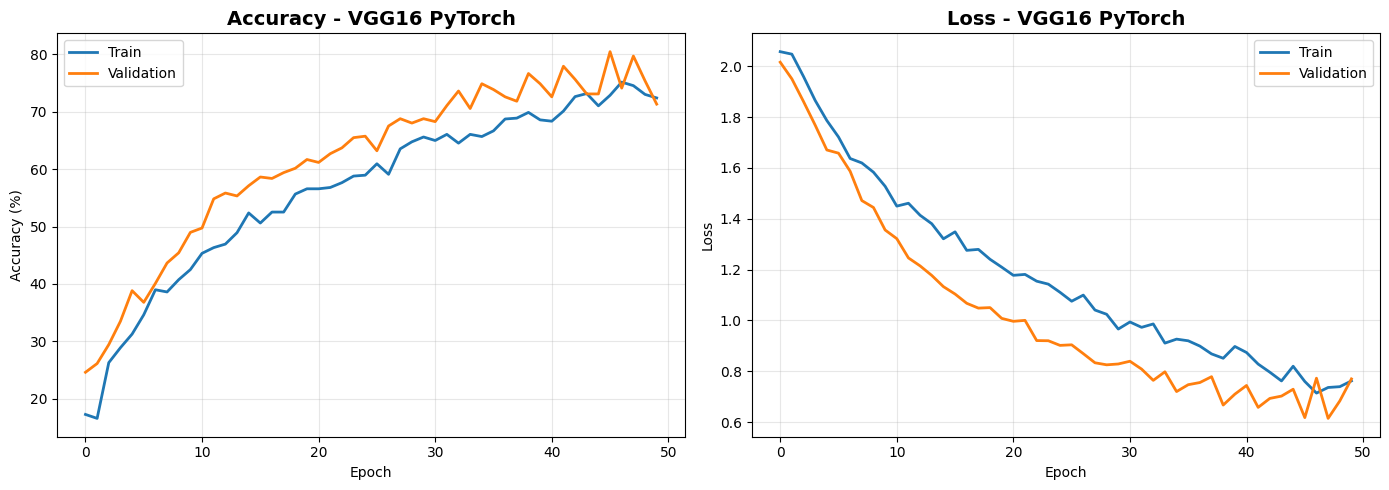

In [11]:
print("ÉTAPE 5: Evaluation")
#on charge le meilleur modèle pour lévaluer sur des données non vues lors de l'entrainement 
model.load_state_dict(torch.load('/kaggle/working/vgg16_best.pth'))
model.eval()

y_true = []
y_pred = []
#prédictions sur le test set 
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
#accuracy finale (vraie performance du modèle)
test_acc = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")

#visualisation des résultats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'], label='Train', linewidth=2)
axes[0].plot(history['val_acc'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy - VGG16 PyTorch', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train', linewidth=2)
axes[1].plot(history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss - VGG16 PyTorch', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/vgg16_training.png', dpi=150)
plt.show()

ÉTAPE 6: MATRICE DE CONFUSION


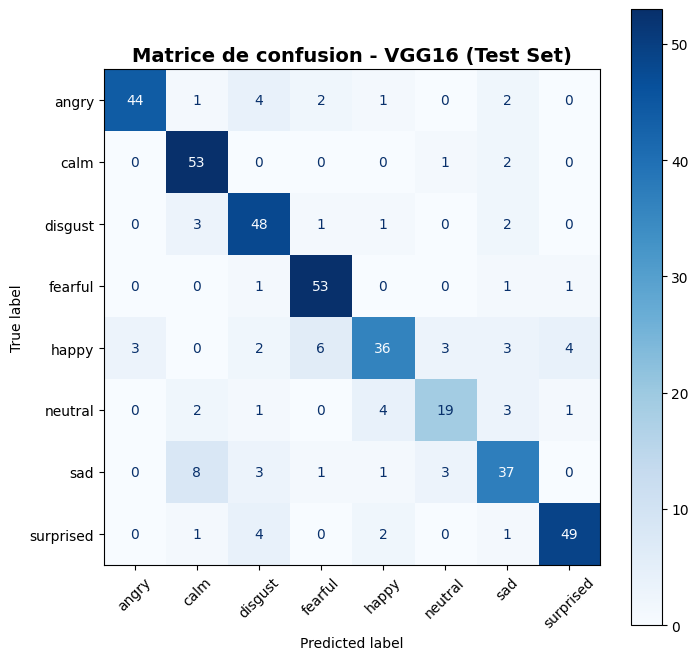

In [12]:
print("ÉTAPE 6: MATRICE DE CONFUSION")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Récupération des noms des classes (émotions)
class_names = list(train_dataset.class_to_idx.keys())

# Affichage de la matrice de confusion
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Matrice de confusion - VGG16 (Test Set)", fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()


In [13]:
print("\nÉTAPE 7: CALCUL DU TEMPS D'INFÉRENCE")

import time

model.eval()

# Warmup
with torch.no_grad():
    for i, (X_batch, _) in enumerate(test_loader):
        if i >= 3:
            break
        X_batch = X_batch.to(device)
        _ = model(X_batch)

# Mesure du temps
start_time = time.time()

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        _ = model(X_batch)

end_time = time.time()

time_per_image = ((end_time - start_time) / len(test_dataset)) * 1000

print(f"Temps par image: {time_per_image:.2f} ms")


print("VGG16 PYTORCH TERMINÉ!")


ÉTAPE 7: CALCUL DU TEMPS D'INFÉRENCE
Temps par image: 3.25 ms
VGG16 PYTORCH TERMINÉ!
